## Funnel & Retention Analysis [Multi-Category Online Store (Kaggle Dataset)]


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [24]:
df = pd.read_csv("C:\\Users\\sniks\\OneDrive\\Desktop\\ecom\\2019-Oct.csv")

In [25]:
print("  DATA QUALITY")

print(f"\n  Shape: {df.shape[0]:>12,} rows × {df.shape[1]} cols")
print(f"Duplicates: {df.duplicated().sum():>12,}")
print(f"\nEvent distribution:")
print(df["event_type"].value_counts().to_string())

before = len(df)
df.drop_duplicates(inplace=True)
print(f"\n Duplicates removed: {before - len(df):,}")

df.dropna(subset=["event_time", "event_type", "user_id"], inplace=True)

VALID = ["view", "cart", "remove_from_cart", "purchase"]
df = df[df["event_type"].isin(VALID)].copy()

df = df[df["price"] > 0].copy()

df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

if df["event_time"].dt.tz is None:
    df["event_time"] = df["event_time"].dt.tz_localize("UTC")
else:
    df["event_time"] = df["event_time"].dt.tz_convert("UTC")

df["date"]= df["event_time"].dt.date
df["date"]= pd.to_datetime(df["date"])
df["hour"]= df["event_time"].dt.hour.astype("int8")
df["day_of_week"] = df["event_time"].dt.day_name().astype("category")
df["week"]= df["event_time"].dt.isocalendar().week.astype("int8")
df["is_weekend"]= df["day_of_week"].isin(["Saturday", "Sunday"])

df["top_category"] = (df["category_code"].astype(str).str.split(".").str[0].replace("nan", np.nan).astype("category"))

print(f"\n CLEAN dataset: {len(df):>12,} rows")
print(f"Date range: {df['event_time'].min().date()} → {df['event_time'].max().date()}")
print(f"Unique users: {df['user_id'].nunique():>12,}")
print(f"Unique products: {df['product_id'].nunique():>12,}")
print(f"Unique brands: {df['brand'].nunique():>12,}")

  DATA QUALITY

  Shape:   42,448,764 rows × 9 cols
Duplicates:       30,220

Event distribution:
event_type
view        40779399
cart          926516
purchase      742849

 Duplicates removed: 30,220

 CLEAN dataset:   42,349,874 rows
Date range: 2019-10-01 → 2019-10-31
Unique users:    3,021,435
Unique products:      165,647
Unique brands:        3,444


In [26]:
PALETTE = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#10B981", "#6B7280"]
sns.set_palette(PALETTE)

## EDA

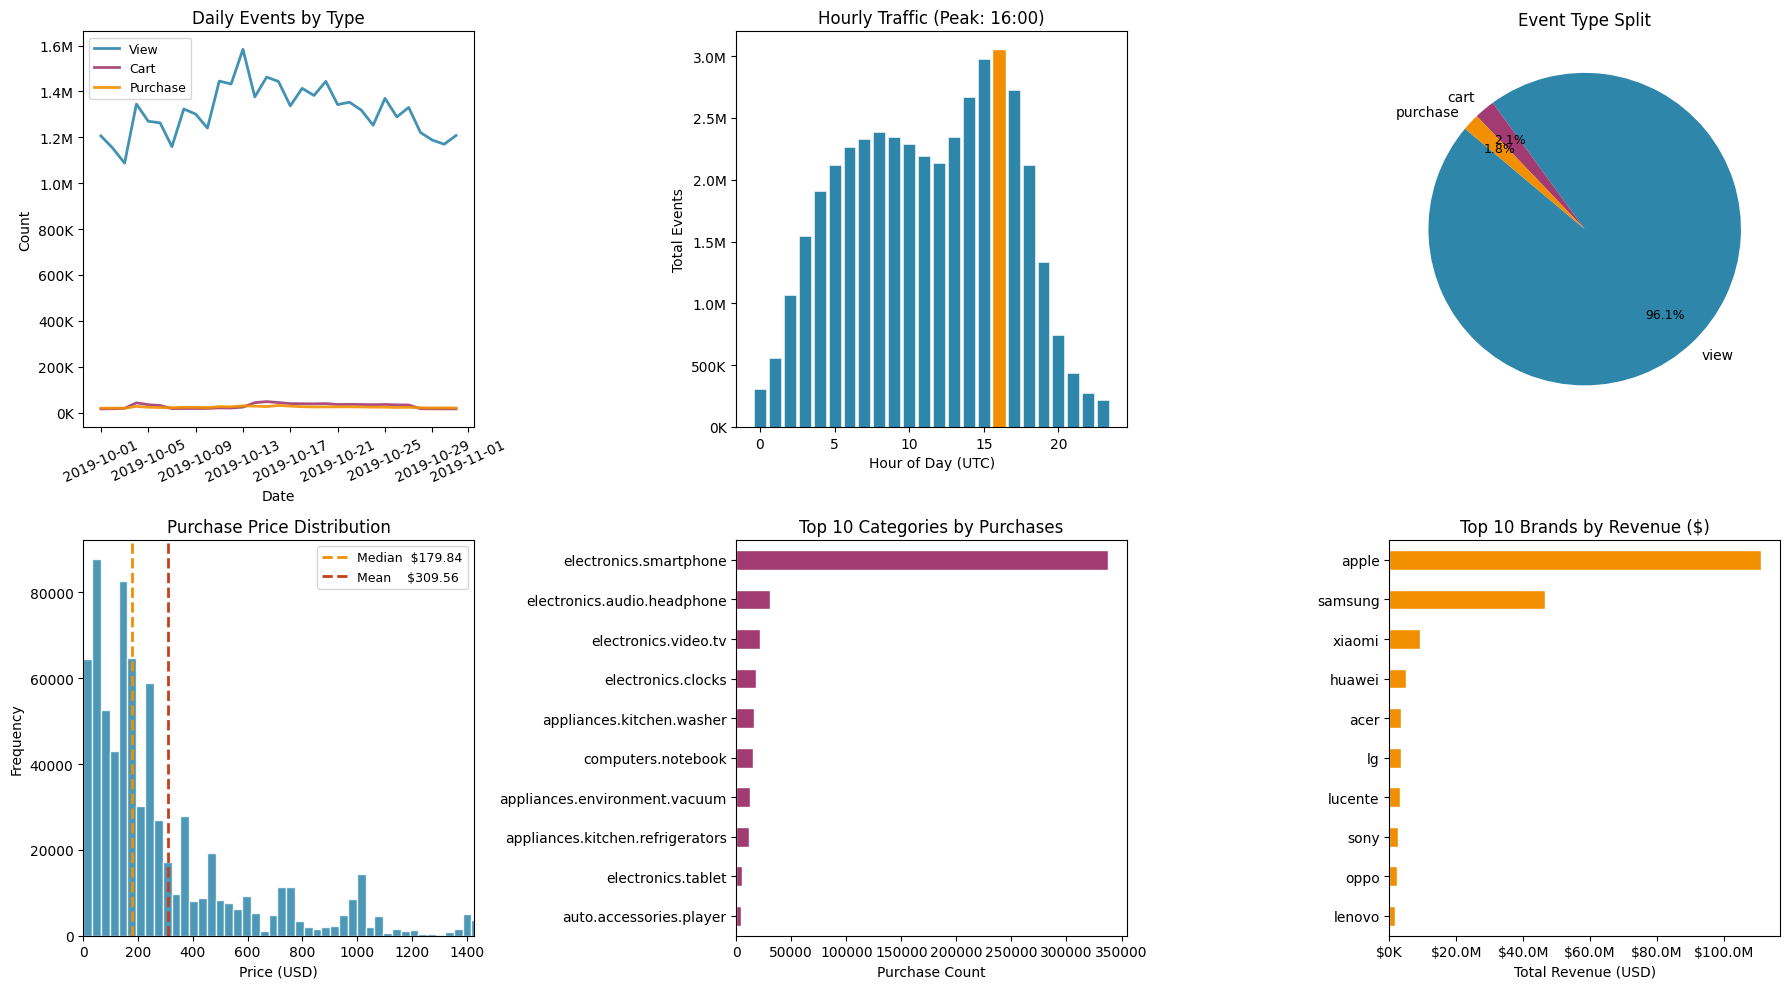

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
daily = df.groupby(["date", "event_type"]).size().unstack(fill_value=0)
for col, color in zip(["view", "cart", "purchase"], PALETTE):
    if col in daily.columns:
        ax.plot(daily.index, daily[col], label=col.capitalize(), color=color, linewidth=2, alpha=0.9)
ax.set_title("Daily Events by Type")
ax.set_xlabel("Date"); ax.set_ylabel("Count")
ax.legend(fontsize=9); ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K"))

ax = axes[0, 1]
hourly = df.groupby("hour").size().reset_index(name="count")
bars = ax.bar(hourly["hour"], hourly["count"], color=PALETTE[0], edgecolor="white", linewidth=0.4)
peak_h = hourly.loc[hourly["count"].idxmax(), "hour"]
bars[peak_h].set_color(PALETTE[2])
ax.set_title(f"Hourly Traffic (Peak: {peak_h}:00)")
ax.set_xlabel("Hour of Day (UTC)"); ax.set_ylabel("Total Events")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K"))

ax = axes[0, 2]
ev_counts = df["event_type"].value_counts()
wedges, texts, autotexts = ax.pie(ev_counts.values, labels=ev_counts.index,
    autopct="%1.1f%%", colors=PALETTE[:len(ev_counts)],
    pctdistance=0.75, startangle=140)
for at in autotexts: at.set_fontsize(9)
ax.set_title("Event Type Split")

ax = axes[1, 0]
purchase_prices = df[df["event_type"] == "purchase"]["price"]
ax.hist(purchase_prices, bins=80, color=PALETTE[0], edgecolor="white", alpha=0.85)
ax.axvline(purchase_prices.median(), color=PALETTE[2], linestyle="--", lw=2,
           label=f"Median  ${purchase_prices.median():.2f}")
ax.axvline(purchase_prices.mean(), color=PALETTE[3], linestyle="--", lw=2,
           label=f"Mean    ${purchase_prices.mean():.2f}")
ax.set_title("Purchase Price Distribution")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Frequency")
ax.legend(fontsize=9)
ax.set_xlim(0, purchase_prices.quantile(0.98))

ax = axes[1, 1]
top_cats = (df[(df["event_type"] == "purchase") & df["category_code"].notna()]
            .groupby("category_code").size().nlargest(10).sort_values())
top_cats.plot(kind="barh", ax=ax, color=PALETTE[1], edgecolor="white")
ax.set_title("Top 10 Categories by Purchases")
ax.set_xlabel("Purchase Count"); ax.set_ylabel("")

ax = axes[1, 2]
top_brands = (df[(df["event_type"] == "purchase") & df["brand"].notna()]
              .groupby("brand")["price"].sum().nlargest(10).sort_values())
top_brands.plot(kind="barh", ax=ax, color=PALETTE[2], edgecolor="white")
ax.set_title("Top 10 Brands by Revenue ($)")
ax.set_xlabel("Total Revenue (USD)"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M" if x>=1e6 else f"${x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight", dpi=150)
plt.show()

## Funnel Analysis

In [28]:
viewers= df[df["event_type"] == "view"]["user_id"].nunique()
carters= df[df["event_type"] == "cart"]["user_id"].nunique()
removers= df[df["event_type"] == "remove_from_cart"]["user_id"].nunique()
purchasers= df[df["event_type"] == "purchase"]["user_id"].nunique()

view_to_cart= carters/viewers* 100
cart_to_purchase= purchasers/carters * 100
overall_cvr= purchasers/viewers* 100
cart_abandon= 100 - cart_to_purchase

total_views= (df["event_type"] == "view").sum()
total_carts = (df["event_type"] == "cart").sum()
total_purchases = (df["event_type"] == "purchase").sum()
total_revenue= df[df["event_type"] == "purchase"]["price"].sum()
avg_order_value= df[df["event_type"] == "purchase"]["price"].mean()

print("FUNNEL ANALYSIS")
print(f"{'Stage':<20} {'Unique Users':>15} {'% of Viewers':>15}")
print(f"{'-'*50}")
for stage, count in [('View', viewers), ('Add to Cart', carters), ('Purchase', purchasers)]:
    print(f"{stage:<20} {count:>15,} {count/viewers*100:>14.2f}%")
print()
print(f" View → Cart conversion: {view_to_cart:.2f}%  ({100-view_to_cart:.2f}% drop-off)")
print(f"Cart → Purchase rate: {cart_to_purchase:.2f}% ({cart_abandon:.2f}% abandon rate)")
print(f"Overall CVR (View→Buy): {overall_cvr:.4f}%")
print()
print(f"Total Revenue: ${total_revenue:>15,.2f}")
print(f"Average Order Value: ${avg_order_value:>15,.2f}")
print(f" Total Purchase Events: {total_purchases:>15,}")


funnel = dict(viewers=viewers, carters=carters, purchasers=purchasers,
    view_to_cart=view_to_cart, cart_to_purchase=cart_to_purchase,
    overall_cvr=overall_cvr, cart_abandon=cart_abandon,
    total_revenue=total_revenue, avg_order_value=avg_order_value,
    total_purchases=total_purchases)


FUNNEL ANALYSIS
Stage                   Unique Users    % of Viewers
--------------------------------------------------
View                       3,021,273         100.00%
Add to Cart                  337,082          11.16%
Purchase                     347,118          11.49%

 View → Cart conversion: 11.16%  (88.84% drop-off)
Cart → Purchase rate: 102.98% (-2.98% abandon rate)
Overall CVR (View→Buy): 11.4891%

Total Revenue: $ 229,933,212.63
Average Order Value: $         309.56
 Total Purchase Events:         742,773


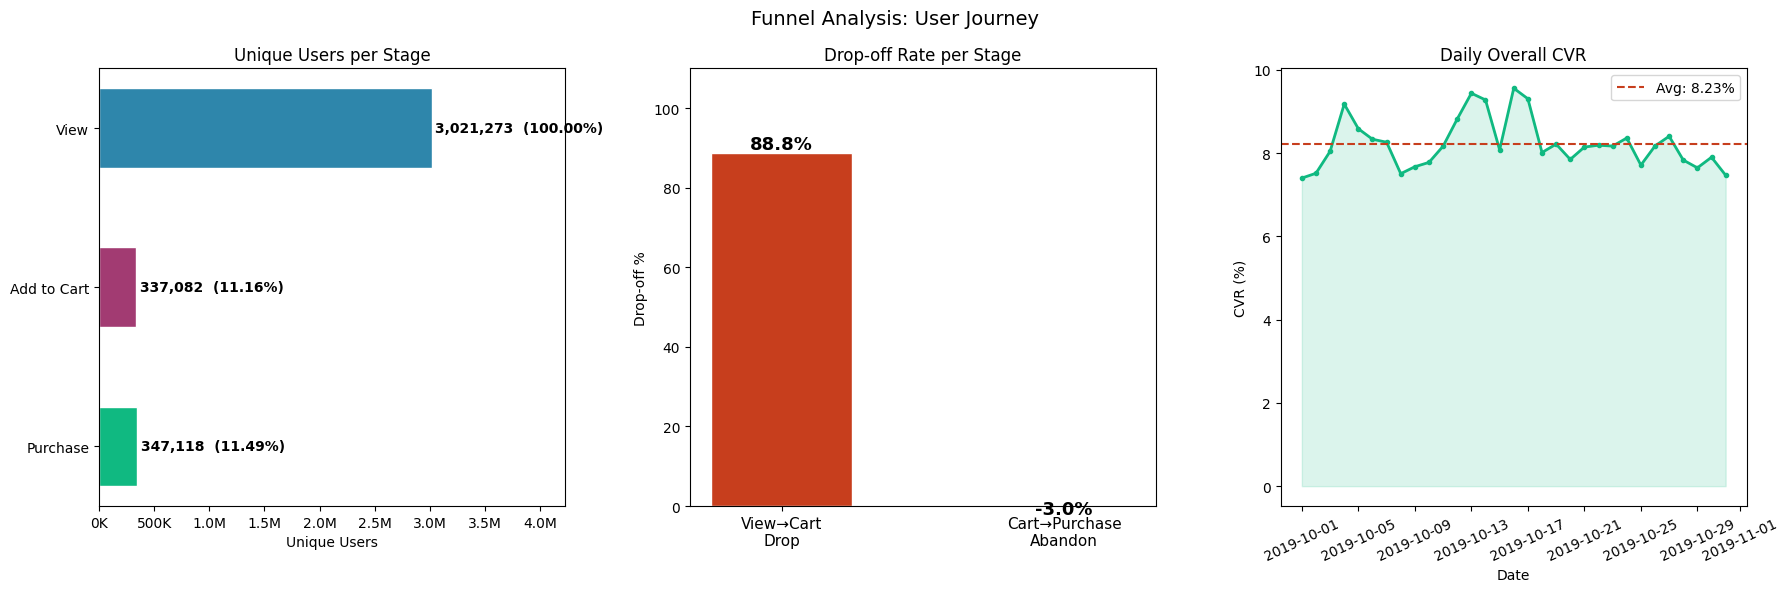

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Funnel Analysis: User Journey", fontsize=14)

stages  = ["View", "Add to Cart", "Purchase"]
counts  = [viewers, carters, purchasers]
colors  = [PALETTE[0], PALETTE[1], PALETTE[4]]
bars = axes[0].barh(stages[::-1], counts[::-1], color=colors[::-1],
                    edgecolor="white", height=0.5)
for bar, count in zip(bars, counts[::-1]):
    axes[0].text(bar.get_width() + max(counts)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"{count:,}  ({count/viewers*100:.2f}%)",
                 va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, max(counts) * 1.4)
axes[0].set_title("Unique Users per Stage"); axes[0].set_xlabel("Unique Users")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M" if x>=1e6 else f"{x/1e3:.0f}K"))

drop_labels = ["View→Cart\nDrop", "Cart→Purchase\nAbandon"]
drop_pcts   = [100 - view_to_cart, cart_abandon]
bars2 = axes[1].bar([0, 1], drop_pcts, color=[PALETTE[3], PALETTE[2]],
                    edgecolor="white", width=0.5)
for bar, pct in zip(bars2, drop_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{pct:.1f}%", ha="center", fontsize=13, fontweight="bold")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(drop_labels, fontsize=11)
axes[1].set_ylabel("Drop-off %"); axes[1].set_ylim(0, 110)
axes[1].set_title("Drop-off Rate per Stage")

daily_v = df[df["event_type"]=="view"].groupby("date")["user_id"].nunique()
daily_p = df[df["event_type"]=="purchase"].groupby("date")["user_id"].nunique()
daily_cvr = (daily_p / daily_v * 100).dropna()
axes[2].plot(daily_cvr.index, daily_cvr.values, color=PALETTE[4], linewidth=2, marker="o", markersize=3)
axes[2].fill_between(daily_cvr.index, daily_cvr.values, alpha=0.15, color=PALETTE[4])
axes[2].axhline(daily_cvr.mean(), color=PALETTE[3], linestyle="--", linewidth=1.5,
                label=f"Avg: {daily_cvr.mean():.2f}%")
axes[2].set_title("Daily Overall CVR"); axes[2].set_xlabel("Date")
axes[2].set_ylabel("CVR (%)"); axes[2].legend()
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("funnel_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

## Cohort Retention Analysis

In [30]:
user_first = (df.groupby("user_id")["event_time"].min().reset_index().rename(columns={"event_time": "first_event_time"}))
user_first["cohort_week"] = (user_first["first_event_time"].dt.isocalendar().week.astype(int))

df_coh = df.merge(user_first[["user_id", "cohort_week"]], on="user_id")
df_coh["event_week"]  = df_coh["event_time"].dt.isocalendar().week.astype(int)
df_coh["week_number"] = (df_coh["event_week"] - df_coh["cohort_week"]).clip(lower=0)

cohort_counts = (df_coh.groupby(["cohort_week", "week_number"])["user_id"].nunique().reset_index())
cohort_pivot  = cohort_counts.pivot(index="cohort_week", columns="week_number", values="user_id")
cohort_sizes  = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_sizes, axis=0) * 100

retention_pct.index   = [f"Week {w}" for w in retention_pct.index]
retention_pct.columns = [f"W+{c}"    for c in retention_pct.columns]

print("\n Cohort Retention Matrix (% still active):")
print(retention_pct.round(1).to_string())

w1_col = "W+1" if "W+1" in retention_pct.columns else retention_pct.columns[1] if len(retention_pct.columns)>1 else None
w2_col = "W+2" if "W+2" in retention_pct.columns else None
if w1_col:
    avg_w1 = retention_pct[w1_col].mean()
    print(f"\n  Avg Week+1 Retention : {avg_w1:.1f}%")
if w2_col:
    avg_w2 = retention_pct[w2_col].mean()
    print(f"  Avg Week+2 Retention : {avg_w2:.1f}%")



 Cohort Retention Matrix (% still active):
           W+0   W+1   W+2   W+3   W+4
Week 40  100.0  35.6  32.1  27.8  17.4
Week 41  100.0  27.2  22.1  12.7   NaN
Week 42  100.0  22.4  11.4   NaN   NaN
Week 43  100.0  12.5   NaN   NaN   NaN
Week 44  100.0   NaN   NaN   NaN   NaN

  Avg Week+1 Retention : 24.4%
  Avg Week+2 Retention : 21.9%


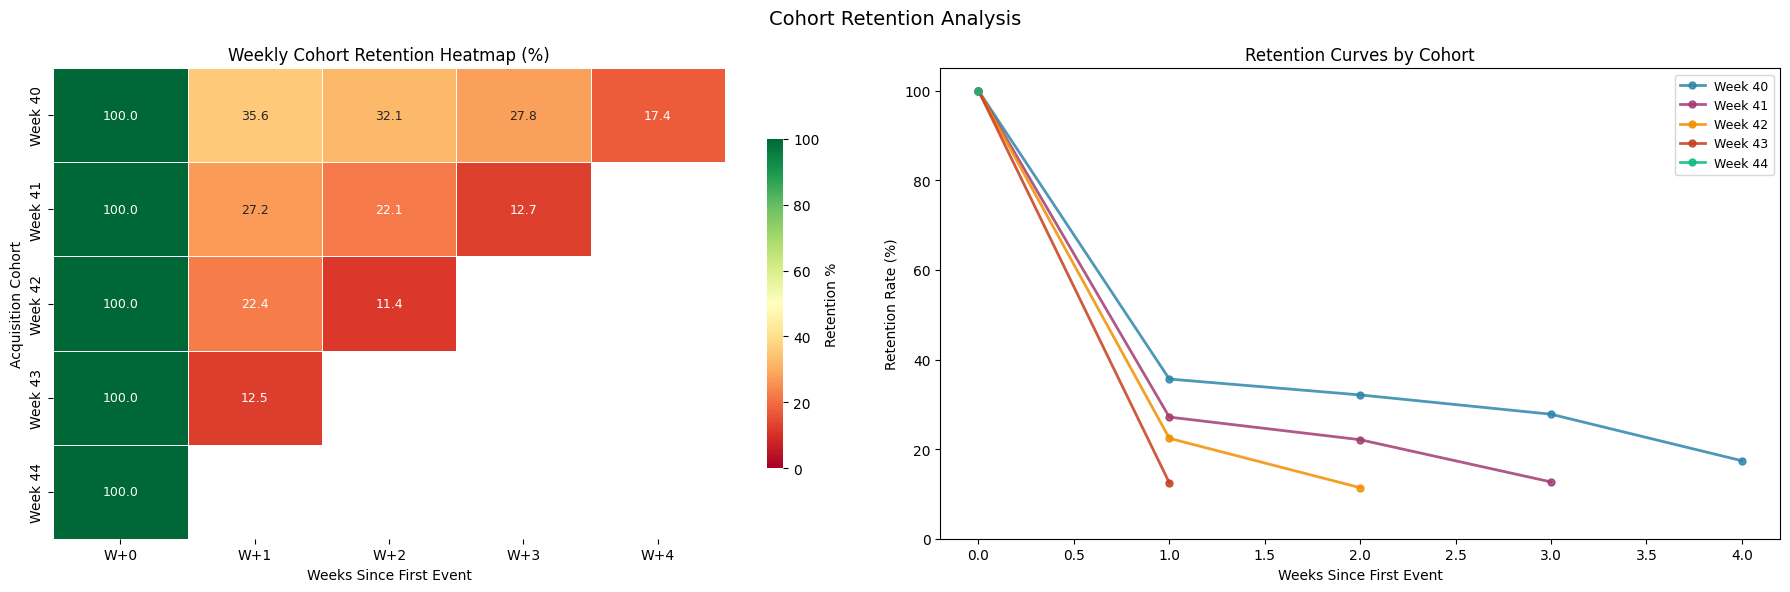

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Cohort Retention Analysis", fontsize=14)

ax = axes[0]
sns.heatmap(retention_pct, ax=ax, annot=True, fmt=".1f", cmap="RdYlGn", mask=retention_pct.isna(), linewidths=0.5, linecolor="white", annot_kws={"size": 9},vmin=0, vmax=100,cbar_kws={"label": "Retention %", "shrink": 0.7})
ax.set_title("Weekly Cohort Retention Heatmap (%)")
ax.set_xlabel("Weeks Since First Event")
ax.set_ylabel("Acquisition Cohort")

ax = axes[1]
for i, (idx, row) in enumerate(retention_pct.iterrows()):
    valid = row.dropna()
    ax.plot(
        range(len(valid)), valid.values,
        marker="o", linewidth=2, markersize=5,
        color=PALETTE[i % len(PALETTE)],
        label=idx, alpha=0.85
    )
ax.set_xlabel("Weeks Since First Event")
ax.set_ylabel("Retention Rate (%)")
ax.set_title("Retention Curves by Cohort")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("cohort_retention.png", bbox_inches="tight", dpi=150)
plt.show()

## Compute KPI

In [32]:
total_users      = df["user_id"].nunique()
total_sessions   = df["user_session"].nunique()
total_events     = len(df)

purchase_df      = df[df["event_type"] == "purchase"]
repeat_counts    = purchase_df.groupby("user_id").size()
repeat_users     = (repeat_counts > 1).sum()
repeat_rate      = repeat_users / purchasers * 100 if purchasers > 0 else 0

all_user_ids     = set(df["user_id"])
engaged          = set(df[df["event_type"].isin(["cart","purchase"])]["user_id"])
bounce_rate      = (1 - len(engaged)/len(all_user_ids)) * 100

sessions_per_u   = total_sessions / total_users
revenue_per_user = total_revenue / total_users

weekend_purch = df[(df["event_type"]=="purchase") & df["is_weekend"]]["price"].sum()
weekday_purch = total_revenue - weekend_purch

kpis = {
    "Total Events": f"{total_events:,}",
    "Unique Users" : f"{total_users:,}",
    "Total Sessions" : f"{total_sessions:,}",
    "Sessions / User": f"{sessions_per_u:.2f}",
    "Overall CVR": f"{overall_cvr:.4f}%",
    "View → Cart Rate": f"{view_to_cart:.2f}%",
    "Cart → Purchase Rate": f"{cart_to_purchase:.2f}%",
    "Cart Abandonment Rate": f"{cart_abandon:.2f}%",
    "Total Revenue": f"${total_revenue:,.2f}",
    "Avg Order Value" : f"${avg_order_value:.2f}",
    "Revenue / User": f"${revenue_per_user:.4f}",
    "Repeat Purchase Rate": f"{repeat_rate:.2f}%",
    "Bounce Rate": f"{bounce_rate:.2f}%",
    "Weekend Revenue": f"${weekend_purch:,.2f}",
    "Weekday Revenue": f"${weekday_purch:,.2f}",}

print("KEY PERFORMANCE INDICATORS")
for k, v in kpis.items():
    print(f"  {k:<28}: {v:>15}")


KEY PERFORMANCE INDICATORS
  Total Events                :      42,349,874
  Unique Users                :       3,021,435
  Total Sessions              :       9,239,402
  Sessions / User             :            3.06
  Overall CVR                 :        11.4891%
  View → Cart Rate            :          11.16%
  Cart → Purchase Rate        :         102.98%
  Cart Abandonment Rate       :          -2.98%
  Total Revenue               : $229,933,212.63
  Avg Order Value             :         $309.56
  Revenue / User              :        $76.1007
  Repeat Purchase Rate        :          37.86%
  Bounce Rate                 :          84.07%
  Weekend Revenue             :  $59,036,422.18
  Weekday Revenue             : $170,896,790.45


## KPI

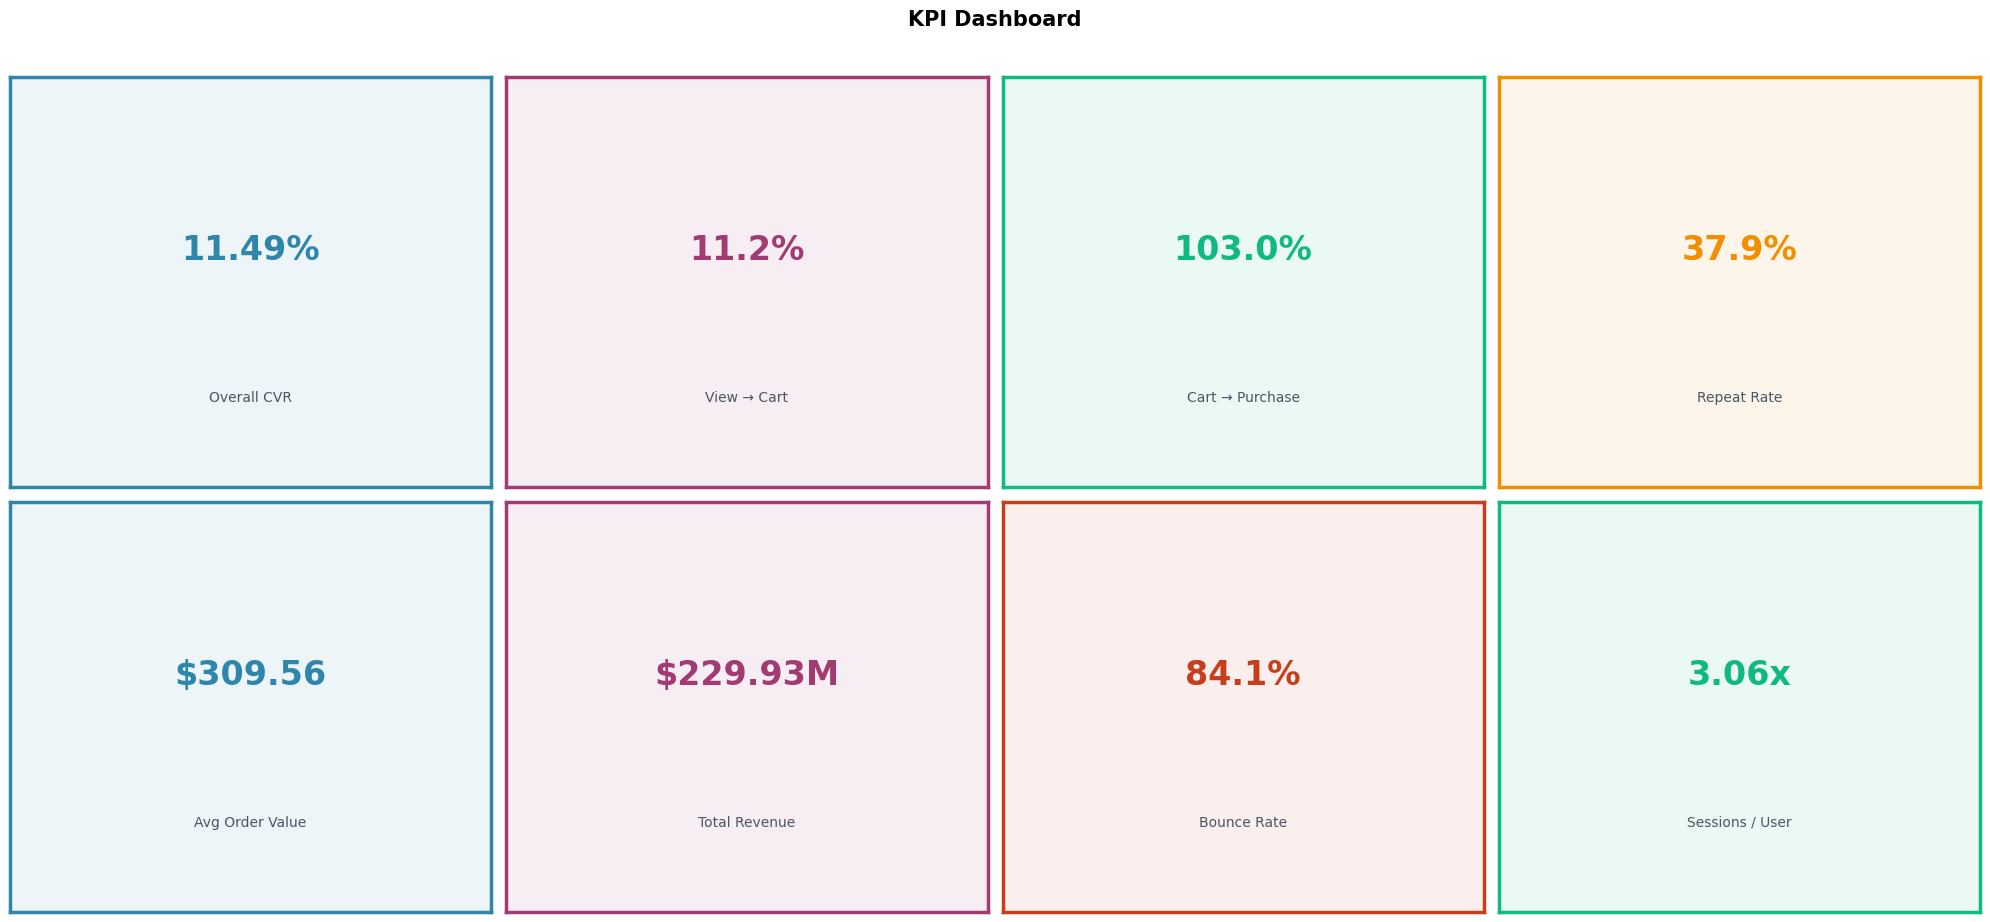

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("KPI Dashboard", fontsize=15, fontweight="bold", y=1.02)

cards = [
    ("Overall CVR", f"{overall_cvr:.2f}%", PALETTE[0]),
    ("View → Cart", f"{view_to_cart:.1f}%", PALETTE[1]),
    ("Cart → Purchase", f"{cart_to_purchase:.1f}%", PALETTE[4]),
    ("Repeat Rate", f"{repeat_rate:.1f}%",   PALETTE[2]),
    ("Avg Order Value", f"${avg_order_value:.2f}", PALETTE[0]),
    ("Total Revenue", f"${total_revenue/1e6:.2f}M", PALETTE[1]),
    ("Bounce Rate", f"{bounce_rate:.1f}%",   PALETTE[3]),
    ("Sessions / User", f"{sessions_per_u:.2f}x", PALETTE[4]),
]

for ax, (label, val, color) in zip(axes.flat, cards):
    ax.set_facecolor(color + "15")
    for sp in ax.spines.values():
        sp.set_color(color); sp.set_linewidth(2.5)
    ax.text(0.5, 0.58, val, transform=ax.transAxes, ha="center", va="center",
            fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.22, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color="#4B5563")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig("kpi_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()

## RMF Customer Segmentation

In [34]:
snapshot = df["event_time"].max()

rfm = (
    df[df["event_type"] == "purchase"]
    .groupby("user_id")
    .agg(
        Recency   = ("event_time",  lambda x: (snapshot - x.max()).days),
        Frequency = ("product_id",  "count"),
        Monetary  = ("price",       "sum"),).reset_index())

print(f"  RFM built for {len(rfm):,} purchasing users")

rfm["R"] = pd.cut(rfm["Recency"].rank(ascending=False, method="first"),  bins=5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.cut(rfm["Frequency"].rank(ascending=True,  method="first"), bins=5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.cut(rfm["Monetary"].rank(ascending=True,   method="first"), bins=5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM"] = rfm["R"] + rfm["F"] + rfm["M"]

def segment(s):
    if s >= 13: return "Champions"
    if s >= 10: return "Loyal Customers"
    if s >=  7: return "Potential Loyalists"
    if s >=  5: return "At Risk"
    return "Lost / Churned"

rfm["Segment"] = rfm["RFM"].apply(segment)

summary = rfm.groupby("Segment").agg(
    Users      = ("user_id",   "count"),
    Avg_Days   = ("Recency",   "mean"),
    Avg_Orders = ("Frequency", "mean"),
    Avg_Rev    = ("Monetary",  "mean"),
    Total_Rev  = ("Monetary",  "sum"),
).sort_values("Avg_Rev", ascending=False).round(2)

print("\n RFM Segment Summary:")
print(summary.to_string())


  RFM built for 347,118 purchasing users

 RFM Segment Summary:
                      Users  Avg_Days  Avg_Orders  Avg_Rev     Total_Rev
Segment                                                                 
Champions             29754     20.42        4.13  1733.88  5.158999e+07
Loyal Customers      119696     14.17        3.26  1174.15  1.405411e+08
Potential Loyalists  137822     14.23        1.22   231.56  3.191440e+07
At Risk               47804      8.60        1.02   108.31  5.177828e+06
Lost / Churned        12042      3.67        1.00    58.95  7.098568e+05


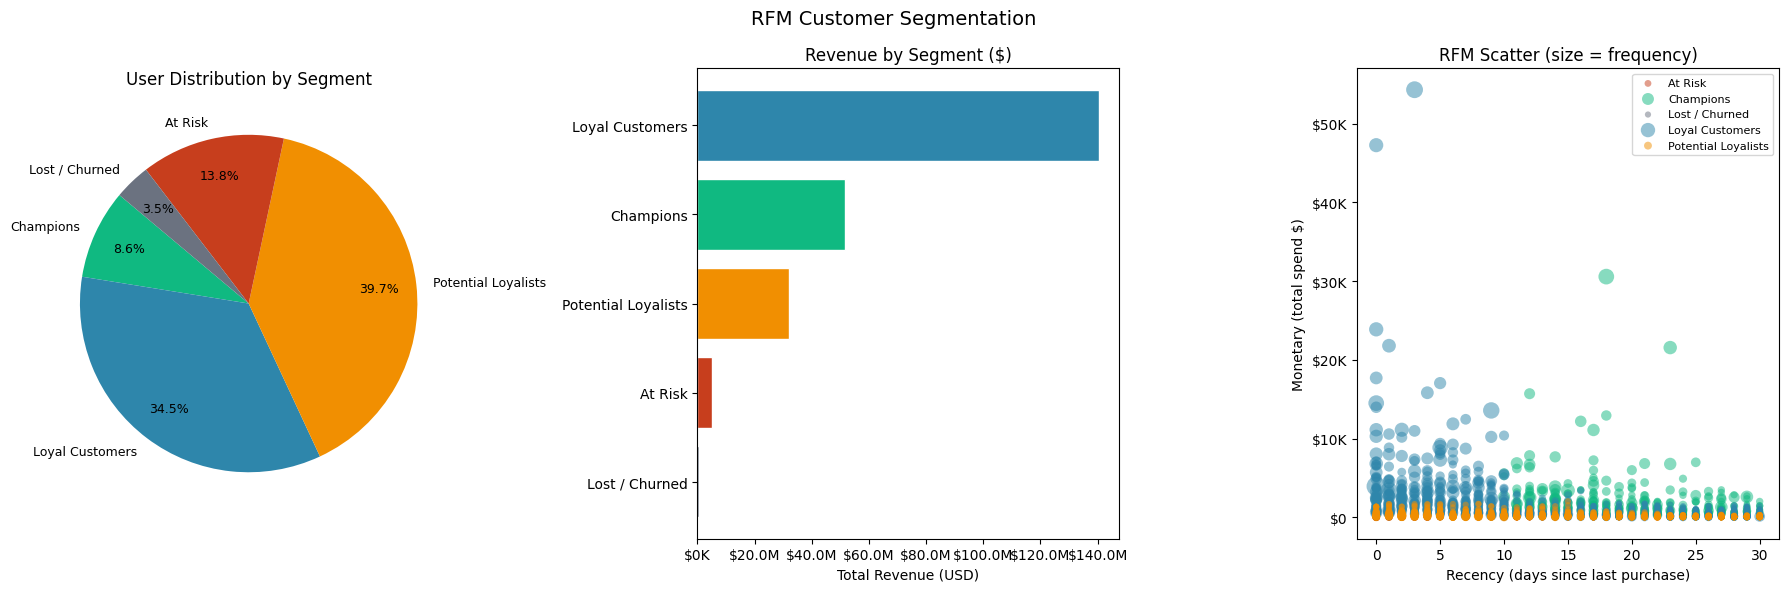

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RFM Customer Segmentation", fontsize=14)

seg_order  = ["Champions","Loyal Customers","Potential Loyalists","At Risk","Lost / Churned"]
seg_colors = [PALETTE[4], PALETTE[0], PALETTE[2], PALETTE[3], PALETTE[5]]
seg_counts = rfm["Segment"].value_counts().reindex(seg_order).fillna(0)
seg_rev    = rfm.groupby("Segment")["Monetary"].sum().reindex(seg_order).fillna(0)

axes[0].pie(seg_counts.values, labels=seg_counts.index,
            colors=seg_colors, autopct="%1.1f%%", startangle=140,
            pctdistance=0.78, textprops={"fontsize": 9})
axes[0].set_title("User Distribution by Segment")

seg_rev_sorted = seg_rev.sort_values()
axes[1].barh(seg_rev_sorted.index, seg_rev_sorted.values,
             color=[seg_colors[seg_order.index(s)] for s in seg_rev_sorted.index],
             edgecolor="white")
axes[1].set_title("Revenue by Segment ($)")
axes[1].set_xlabel("Total Revenue (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.1f}M" if x>=1e6 else f"${x/1e3:.0f}K"))

sample_rfm = rfm.sample(min(5000, len(rfm)), random_state=42)
color_map  = {"Champions": PALETTE[4], "Loyal Customers": PALETTE[0],
              "Potential Loyalists": PALETTE[2], "At Risk": PALETTE[3], "Lost / Churned": PALETTE[5]}
for seg, grp in sample_rfm.groupby("Segment"):
    axes[2].scatter(
        grp["Recency"], grp["Monetary"],
        s=np.sqrt(grp["Frequency"])* 20,
        c=color_map[seg], alpha=0.5, label=seg, edgecolors="none"
    )
axes[2].set_xlabel("Recency (days since last purchase)")
axes[2].set_ylabel("Monetary (total spend $)")
axes[2].set_title("RFM Scatter (size = frequency)")
axes[2].legend(fontsize=8, loc="upper right")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K" if x>=1000 else f"${x:.0f}"))

plt.tight_layout()
plt.savefig("rfm_segmentation.png", bbox_inches="tight", dpi=150)
plt.show()

## Category, Brand & Time Patterns

C:\Users\sniks\AppData\Local\Temp\ipykernel_23472\908175144.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  hmap = df.pivot_table(index="day_of_week", columns="hour",


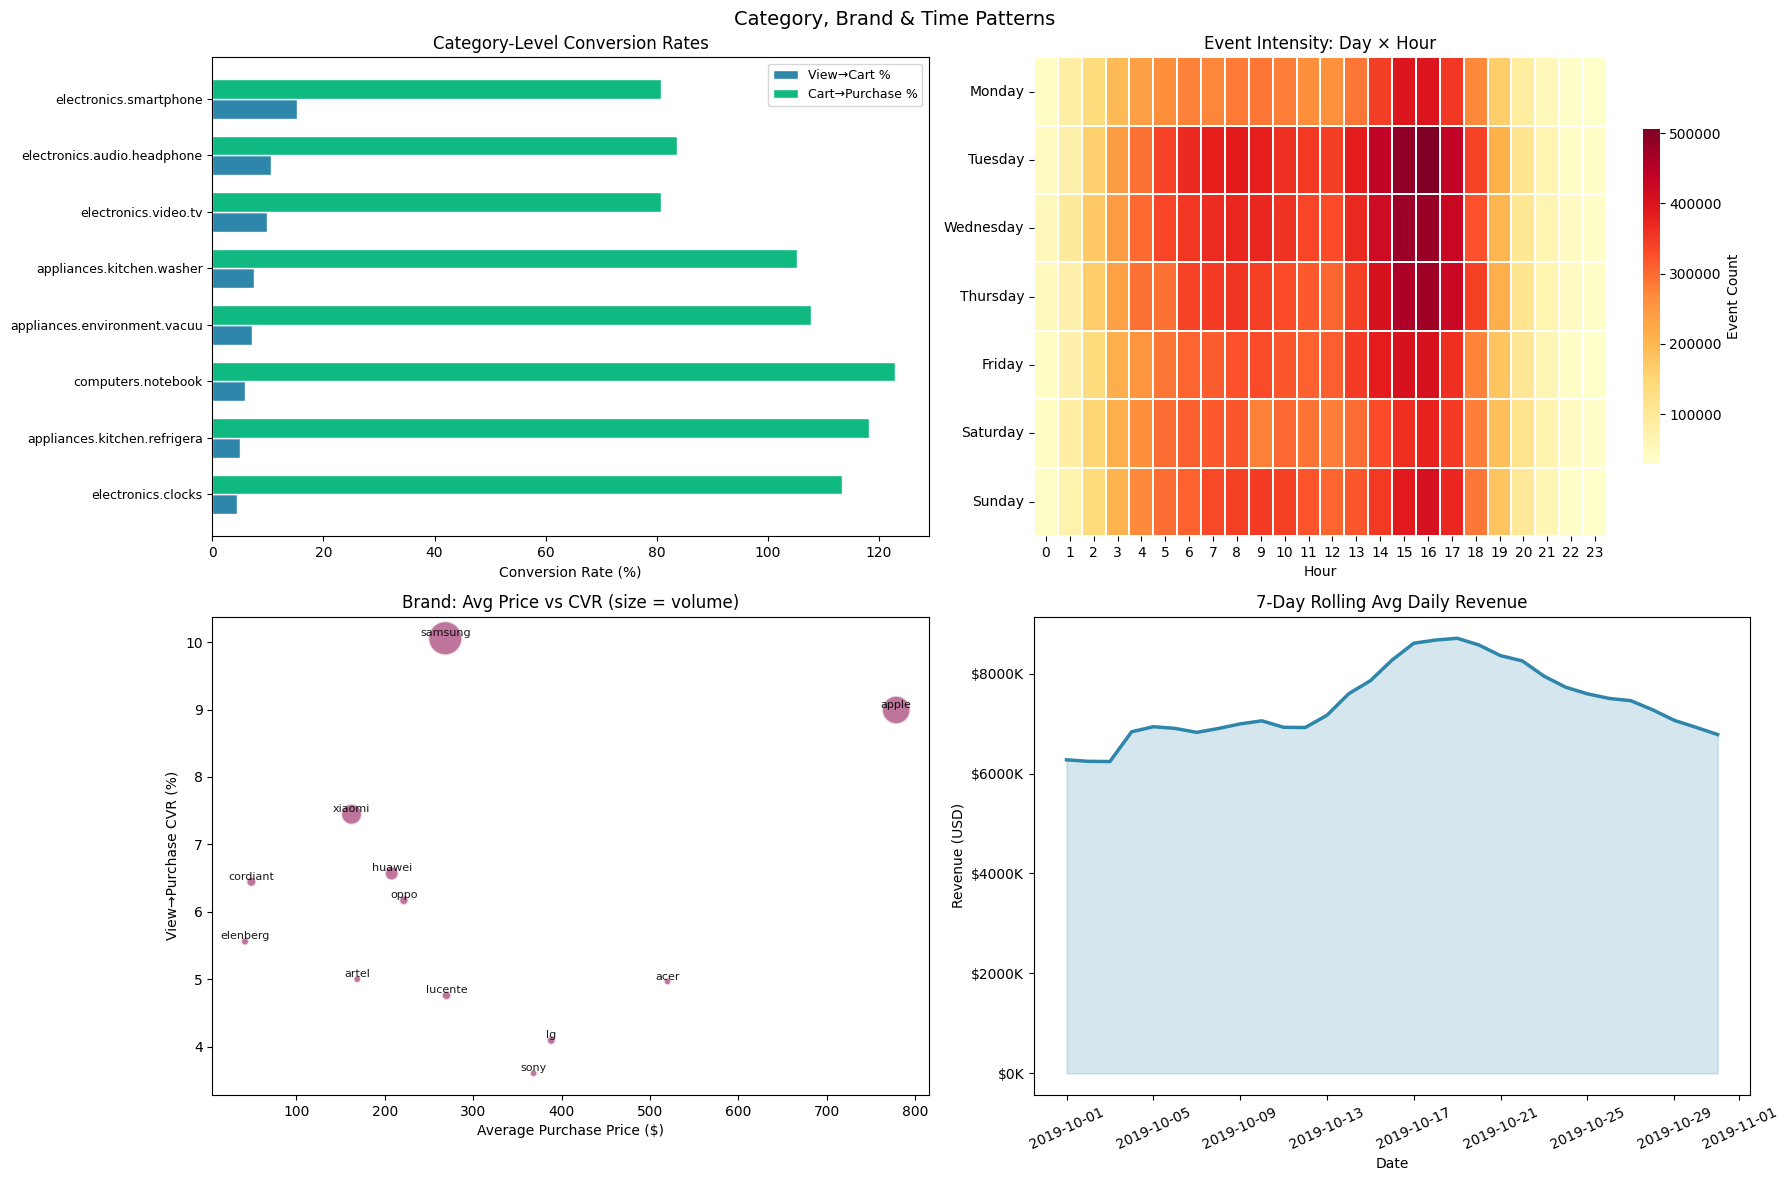

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Category, Brand & Time Patterns", fontsize=14)

ax = axes[0, 0]
top_cat_list = (df[df["event_type"]=="purchase"]
                .dropna(subset=["category_code"])
                .groupby("category_code").size()
                .nlargest(8).index.tolist())

cat_data = {}
for cat in top_cat_list:
    v = df[(df["event_type"]=="view")    & (df["category_code"]==cat)]["user_id"].nunique()
    c = df[(df["event_type"]=="cart")    & (df["category_code"]==cat)]["user_id"].nunique()
    p = df[(df["event_type"]=="purchase")& (df["category_code"]==cat)]["user_id"].nunique()
    cat_data[cat] = {"v2c": c/v*100 if v>0 else 0, "c2p": p/c*100 if c>0 else 0}

cat_df = pd.DataFrame(cat_data).T.sort_values("v2c")
x = np.arange(len(cat_df))
w = 0.35
ax.barh(x - w/2, cat_df["v2c"], w, label="View→Cart %",     color=PALETTE[0], edgecolor="white")
ax.barh(x + w/2, cat_df["c2p"], w, label="Cart→Purchase %", color=PALETTE[4], edgecolor="white")
ax.set_yticks(x); ax.set_yticklabels([c[:28] for c in cat_df.index], fontsize=9)
ax.set_title("Category-Level Conversion Rates"); ax.legend(fontsize=9)
ax.set_xlabel("Conversion Rate (%)")

ax = axes[0, 1]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
hmap = df.pivot_table(index="day_of_week", columns="hour",
                      values="event_type", aggfunc="count")
hmap = hmap.reindex([d for d in day_order if d in hmap.index])
sns.heatmap(hmap, ax=ax, cmap="YlOrRd", linewidths=0.2,
            cbar_kws={"label":"Event Count","shrink":0.7})
ax.set_title("Event Intensity: Day × Hour"); ax.set_xlabel("Hour"); ax.set_ylabel("")

ax = axes[1, 0]
top_b = (df[(df["event_type"]=="purchase") & df["brand"].notna()]
         .groupby("brand").size().nlargest(12).index)
brand_stats = []
for b in top_b:
    v = df[(df["event_type"]=="view")    & (df["brand"]==b)]["user_id"].nunique()
    p = df[(df["event_type"]=="purchase")& (df["brand"]==b)]["user_id"].nunique()
    avg_p = df[(df["event_type"]=="purchase")& (df["brand"]==b)]["price"].mean()
    brand_stats.append({"brand": b, "cvr": p/v*100 if v>0 else 0, "avg_price": avg_p, "purchases": p})
bs = pd.DataFrame(brand_stats)
ax.scatter(bs["avg_price"], bs["cvr"], s=bs["purchases"]/max(bs["purchases"])*600,
           c=PALETTE[1], alpha=0.7, edgecolors="white", linewidth=1.5)
for _, row in bs.iterrows():
    ax.annotate(row["brand"], (row["avg_price"], row["cvr"]),
                fontsize=8, ha="center", va="bottom", alpha=0.9)
ax.set_xlabel("Average Purchase Price ($)"); ax.set_ylabel("View→Purchase CVR (%)")
ax.set_title("Brand: Avg Price vs CVR (size = volume)")

ax = axes[1, 1]
weekly_rev = (df[df["event_type"]=="purchase"]
              .groupby("date")["price"].sum()
              .rolling(7, min_periods=1).mean())
ax.fill_between(weekly_rev.index, weekly_rev.values, alpha=0.2, color=PALETTE[0])
ax.plot(weekly_rev.index, weekly_rev.values, color=PALETTE[0], linewidth=2.5)
ax.set_title("7-Day Rolling Avg Daily Revenue")
ax.set_xlabel("Date"); ax.set_ylabel("Revenue (USD)")
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("advanced_analysis.png", bbox_inches="tight", dpi=150)
plt.show()

## Step 9: Insights

### 🔴 Critical: Funnel Drop-offs
1. **View → Cart gap** is the biggest leak. Only a small fraction of viewers add to cart.  
   Cause: poor product detail page UX, missing social proof, price anchoring.
2. **Cart Abandonment**: complex checkout, unexpected shipping, forced sign-up.

### 🟠 High Retention
3. **Retention cliff at Week+1**: Most users never return after first visit, no re-engagement hooks.
4. **Single-purchase majority**: Most buyers are one-time visitors. LTV is severely under-optimised.

### 🟡 Medium: Product & Pricing
5. **Electronics (smartphone + notebook) dominate** views but may not have proportionally high CVR.  
   Accessories are under-surfaced (cross-sell opportunity).
6. **Price sensitivity**: Mid-range products ($50–$300) convert best. Ultra-premium sees more cart abandonment.

### 🟢 Positive Signals
7. **Repeat purchasers** (those who do buy again) have strong loyalty → target them for LTV programs.
8. **Champions RFM segment**: Small but high-value — respond well to exclusivity, early access.

### Timing
9. **Peak traffic 7–10 PM**: Campaigns, flash sales, push notifications should target this window.
10. **Weekends vs Weekdays**: Analyse revenue split and tailor discount strategies accordingly.

---

## Step 10: Recommendations

| Priority | Initiative | Action | Expected Impact |
|----------|------------|--------|-----------------|
| 🔴 P1 | Abandoned Cart Emails | Auto-email within 1h of cart add; A/B test 5% vs 10% off | +10–15% Cart→Purchase CVR |
| 🔴 P1 | Checkout UX Overhaul | Reduce fields, 1-click for returning users, guest checkout | +8–12% CVR |
| 🟠 P2 | Week-1 Retention Push | Day 3 & Day 7 personalised push with browsed-category deals | +15–20% Week+1 retention |
| 🟠 P2 | Smart Discount Engine | Trigger 5% coupon at cart > $150; cap 2x/user/month | +7% AOV |
| 🟡 P3 | Champions Loyalty Tier | VIP badge, early access, free shipping for top RFM users | +20% repeat rate |
| 🟡 P3 | Cross-sell Engine | "Frequently Bought Together" on smartphone/notebook pages | +5% basket size |
| 🔵 P4 | Real-time Personalisation | Browsed-category homepage for returning users | +12% engagement |

###  A/B Test Roadmap
| Test | Hypothesis | Primary Metric | Duration |
|------|-----------|----------------|----------|
| A | 1-click checkout reduces abandonment | Cart→Purchase CVR | 2 weeks |
| B | Discount popup at cart boosts revenue | Revenue/session | 2 weeks |
| C | 8PM push outperforms 6PM | Notification CTR | 1 week |
| D | "Customers also bought" on PDPs | Basket size | 3 weeks |
